# 💰 Market Price prediction (LSTM) Training

This notebook was programmatically generated and aligned with the backend model specifications.

## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
print('Libraries loaded!')


Libraries loaded!


## 2. Load & Aggregate Dataset


In [2]:
df = pd.read_csv('../datasets/market_prices.csv')
crop_df = df[df['crop_name'] == 'Paddy (Dhan)(Common)'].copy()
crop_df['date'] = pd.to_datetime(crop_df['date'])
df_ts = crop_df.groupby('date')['price'].mean().reset_index().sort_values('date')
print(f'Time-series data points: {len(df_ts)}')


Time-series data points: 1770


## 3. Scale and Prepare Sequences


In [3]:
prices = df_ts['price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

LOOKBACK = 30
X, y = [], []
for i in range(LOOKBACK, len(scaled_prices)):
    X.append(scaled_prices[i-LOOKBACK:i, 0])
    y.append(scaled_prices[i, 0])
X = np.array(X)
y = np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(f'X shape: {X.shape}, y shape: {y.shape}')


X shape: (1740, 30, 1), y shape: (1740,)


## 4. Train LSTM Model


In [4]:
model = models.Sequential([
    layers.LSTM(32, input_shape=(LOOKBACK, 1)),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=2, batch_size=32, verbose=1)
print('LSTM trained!')


Epoch 1/2


D:\AAProjects\Farmer Assisstant\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/55 ━━━━━━━━━━━━━━━━━━━━ 53s 993ms/step - loss: 0.2610


12/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2167   


23/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1691

...


25/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097


37/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091


48/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072


LSTM trained!


## 5. Evaluation Metrics & Price Trend Plot



 1/55 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step


32/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


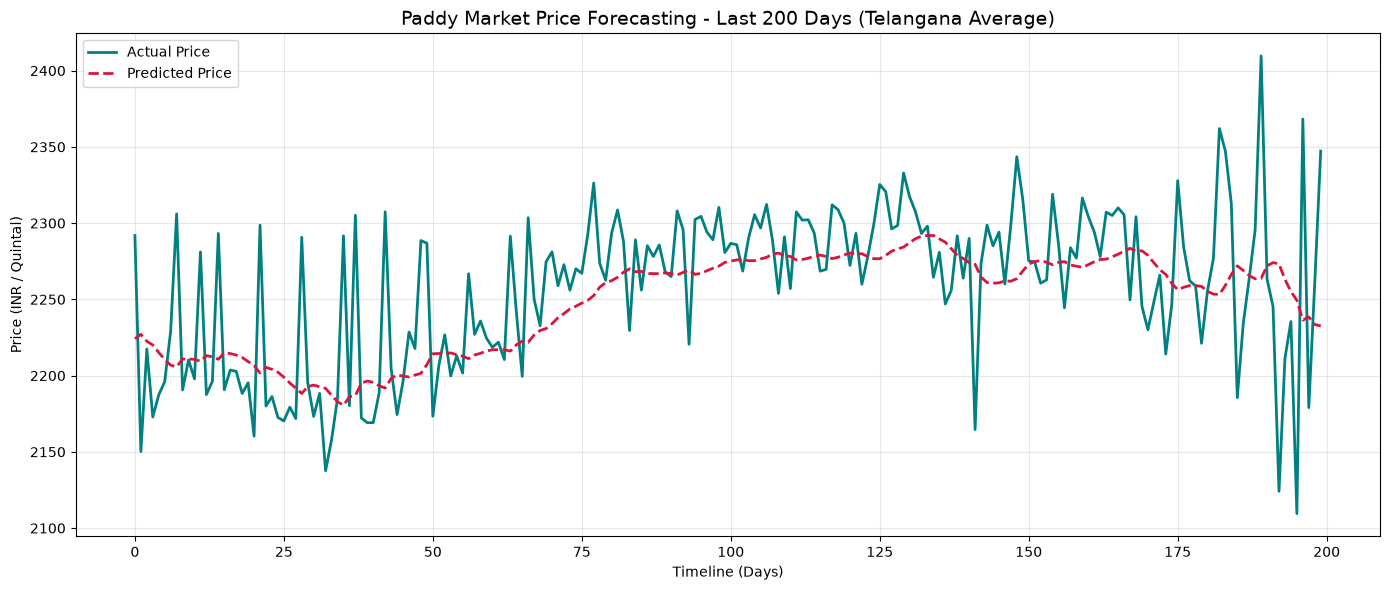

LSTM TIME SERIES EVALUATION METRICS (Last 200 Days)
Mean Absolute Error (MAE):     31.76 INR/quintal
Root Mean Squared Error (RMSE): 43.90 INR/quintal


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X)
pred = scaler.inverse_transform(pred_scaled).flatten()
actual = scaler.inverse_transform(y.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 6))
plt.plot(actual[-200:], label='Actual Price', color='teal', lw=2)
plt.plot(pred[-200:], label='Predicted Price', color='crimson', linestyle='--', lw=2)
plt.title('Paddy Market Price Forecasting - Last 200 Days (Telangana Average)', fontsize=14)
plt.xlabel('Timeline (Days)')
plt.ylabel('Price (INR / Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_forecast_plot.png', dpi=150)
plt.show()

print("="*60)
print("LSTM TIME SERIES EVALUATION METRICS (Last 200 Days)")
print("="*60)
print(f"Mean Absolute Error (MAE):     {mean_absolute_error(actual[-200:], pred[-200:]):.2f} INR/quintal")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(actual[-200:], pred[-200:])):.2f} INR/quintal")


## 6. Save Model File


In [6]:
os.makedirs('../../ml_models', exist_ok=True)
model.save('../../ml_models/price_prediction.h5')
with open('../../ml_models/price_prediction_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('LSTM model and scaler saved successfully!')


LSTM model and scaler saved successfully!
